# Complexity and Velocity of Topics — walkthrough

Companion notebook to *"A Causal Model to Explain Complexity of Topics and Its
Empirical Link with Corpus Velocity"* (Arnaudo, Attarian, Chikhi, Lehalle).

The paper defines the **complexity** of a conceptual marker $M_i$ as its mean
pairwise **lift** against the other markers of its semantic cluster,

$$\ell_{i,j} = \frac{P(M_i=1,\,M_j=1)}{P(M_i=1)\,P(M_j=1)} = e^{\mathrm{PMI}(M_i,M_j)},
\qquad
\mathcal{C}(M_i) = \frac{1}{|\mathcal{S}(M_i)|-1}\sum_{j\in\mathcal{S}(M_i),\,j\neq i}\ell_{i,j},$$

and reports a stylized fact: **publication velocity decreases with complexity**,
consistently across clusters and across sources.

### What this notebook does

| § | Section | Data |
|---|---|---|
| 1 | The generative model — simulate a corpus from a known dependency graph | synthetic |
| 2 | Lift recovers the dependency structure; complexity tracks prerequisite depth | synthetic |
| 3 | The complexity–velocity sign is *not* imposed by the model | synthetic |
| 4 | Recovering the semantic clusters from the lift dissimilarity | synthetic |
| 5 | Recovering the dependency graph with the PC algorithm | synthetic |
| 6 | The stylized fact on the CausalityLink corpus | precomputed |
| 7 | Cross-validation against an LLM judge | precomputed |
| 8 | Source selection as a budget-constrained optimisation | closed form |

**The CausalityLink corpus is proprietary and is not shipped with this repository.**
Sections 1–5 and 8 are fully self-contained. Sections 6–7 read the precomputed
per-cluster results committed under `clusters/`, so the paper's empirical claims
can be checked without access to the corpus. Nothing here needs a GPU; the whole
notebook runs in roughly two minutes on a laptop.

```bash
pip install -r requirements.txt
```

In [1]:
%matplotlib inline
import warnings
from pathlib import Path

# quiet third-party chatter that would otherwise clutter the walkthrough
warnings.filterwarnings("ignore", category=UserWarning, module="umap")
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import roc_auc_score

# helpers from the repository itself
from complexity_clusters import fit_loglog_regression
from marker_clustering import generate_cluster_markers, simulate_markers

CLUSTERS_DIR = Path("clusters")     # precomputed CausalityLink results
RESULTS_DIR = Path("results")       # precomputed benchmark results
SEED = 42

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (7, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("precomputed corpus results:", CLUSTERS_DIR.is_dir(),
      "| benchmark results:", RESULTS_DIR.is_dir())

precomputed corpus results: True | benchmark results: True


---
## 1. The generative model

Each document is a binary vector over $N$ markers. Markers are organised into
layers of increasing conceptual depth: a marker in layer $k$ is drawn
conditionally on its prerequisites in layer $k-1$,

$$P\bigl(M_i = 1 \mid (M_j)_{r_j < r_i}\bigr) = u_i + \sum_{j} C_{j,i}\, M_j,
\qquad u_i + \sum_j C_{j,i} \le 1 .$$

$u_i$ is the exogenous baseline probability of marker $i$, and $C_{j,i}$ the
strength with which prerequisite $j$ pulls $i$ into the document. Below, root
markers are frequent ($u = 0.35$) and deeper markers have essentially no
baseline of their own ($u = 0.001$) — they only appear when their prerequisites
do. The total incoming weight decays by layer, so deeper markers are rarer.

In [2]:
def layered_scm(n_markers, n_layers, n_parents, w0, decay, u_root, u_ramp, rng):
    """A layered structural causal model.

    Every marker in layer k draws ``n_parents`` prerequisites from layer k-1.
    Convention (shared with basevcx / marker_clustering): ``C[i, j] > 0`` means
    j -> i, i.e. marker j is a prerequisite of marker i.

    w0 / decay set the total incoming weight per layer (how strongly a marker is
    pulled in by its prerequisites); u_root / u_ramp set the exogenous baseline
    probability u_i per layer.
    """
    layers = np.array_split(np.arange(n_markers), n_layers)
    C = np.zeros((n_markers, n_markers))
    u = np.zeros(n_markers)
    layer_of = np.zeros(n_markers, dtype=int)

    for k, layer in enumerate(layers):
        layer_of[layer] = k
        u[layer] = u_root * (u_ramp ** k)
        if k == 0:
            continue
        # keep u_i + sum_j C[i, j] <= 1 (the normalisation constraint)
        w_total = min(w0 * decay ** (k - 1), max(0.02, 0.98 - u[layer][0]))
        for target in layer:
            parents = rng.choice(layers[k - 1],
                                 size=min(n_parents, len(layers[k - 1])),
                                 replace=False)
            C[target, parents] = w_total / len(parents)
    return C, u, layer_of


N_MARKERS, N_LAYERS, N_DOCS = 40, 5, 15_000

rng = np.random.default_rng(3)
C, u, layer_of = layered_scm(N_MARKERS, N_LAYERS, n_parents=2, w0=0.8, decay=0.7,
                             u_root=0.35, u_ramp=1.0, rng=rng)
u[layer_of > 0] = 0.001          # deep markers have almost no exogenous baseline
rank = (C != 0).sum(axis=1)      # complexity rank r_i = number of prerequisites

docs = simulate_markers(C, u, n_docs=N_DOCS, rng=rng)
print(f"{docs.shape[0]:,} documents x {docs.shape[1]} markers "
      f"| {docs.sum(axis=1).mean():.1f} markers per document on average")

15,000 documents x 40 markers | 6.1 markers per document on average


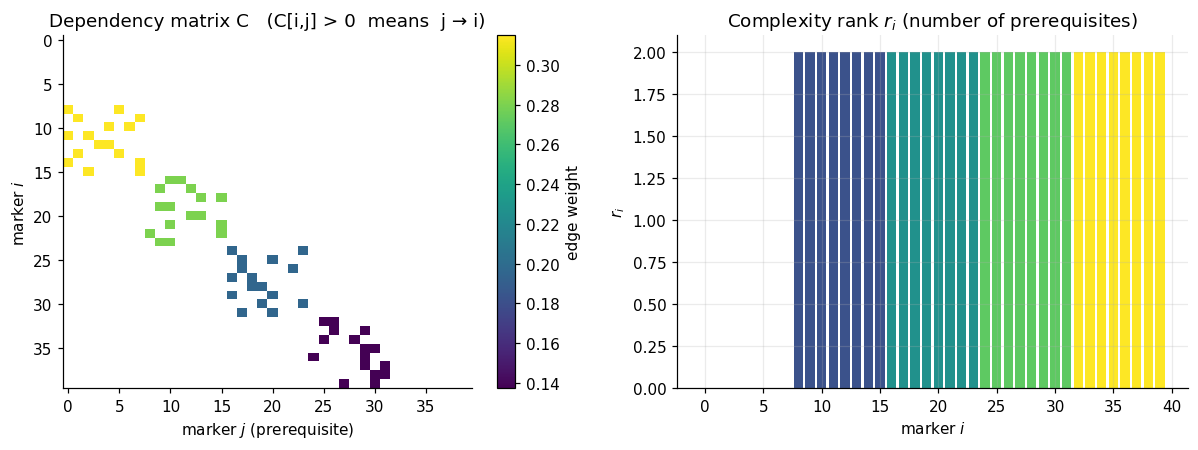

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

im = ax1.imshow(np.where(C > 0, C, np.nan), cmap="viridis",
                aspect="auto", interpolation="nearest")
fig.colorbar(im, ax=ax1, label="edge weight")
ax1.set(title="Dependency matrix C   (C[i,j] > 0  means  j → i)",
        xlabel="marker $j$ (prerequisite)", ylabel="marker $i$")
ax1.grid(False)

ax2.bar(np.arange(N_MARKERS), rank, color=plt.cm.viridis(layer_of / layer_of.max()))
ax2.set(title=r"Complexity rank $r_i$ (number of prerequisites)",
        xlabel="marker $i$", ylabel=r"$r_i$")

fig.tight_layout()
plt.show()

---
## 2. Lift recovers the structure, complexity tracks depth

Only the documents are observable — the matrix $C$ is not. Two checks:

1. **Does the lift see the edges?** Pairs that are true prerequisite edges
   should have systematically higher lift than pairs that are not. We score the
   lift as a binary edge detector (ROC AUC).
2. **Does complexity track conceptual depth?** $\mathcal{C}(M_i)$ knows nothing
   about layers; if the metric works, it should still increase with them.

In [4]:
def lift_matrix_from_documents(docs):
    """Empirical lift(i, j) = P(i, j) / (P(i) P(j)), plus the marginals P(i)."""
    n_docs = docs.shape[0]
    p_i = docs.mean(axis=0)
    p_ij = (docs.T @ docs) / n_docs
    denom = np.outer(p_i, p_i)
    lift = np.divide(p_ij, denom, out=np.zeros_like(p_ij, dtype=float), where=denom > 0)
    return lift, p_i


def complexity_from_lift(lift):
    """C(M_i) = mean off-diagonal lift of marker i against the rest of the cluster."""
    n = lift.shape[0]
    return (lift.sum(axis=1) - np.diag(lift)) / (n - 1)


lift, velocity = lift_matrix_from_documents(docs.astype(float))
complexity = complexity_from_lift(lift)

upper = np.triu_indices(N_MARKERS, k=1)
is_edge = np.maximum(C > 0, (C > 0).T)[upper].astype(int)
auc = roc_auc_score(is_edge, lift[upper])

print(f"true edges                        : {is_edge.sum()} of {len(is_edge)} pairs")
print(f"median lift on true edges         : {np.median(lift[upper][is_edge == 1]):.2f}")
print(f"median lift on non-edges          : {np.median(lift[upper][is_edge == 0]):.2f}")
print(f"ROC AUC of lift as edge detector  : {auc:.3f}")

tau_layer, p_layer = stats.kendalltau(layer_of, complexity)
print(f"Kendall tau(layer, complexity)    : {tau_layer:+.3f}  (p = {p_layer:.1e})")

true edges                        : 64 of 780 pairs
median lift on true edges         : 3.61
median lift on non-edges          : 1.28
ROC AUC of lift as edge detector  : 0.934
Kendall tau(layer, complexity)    : +0.832  (p = 2.4e-12)


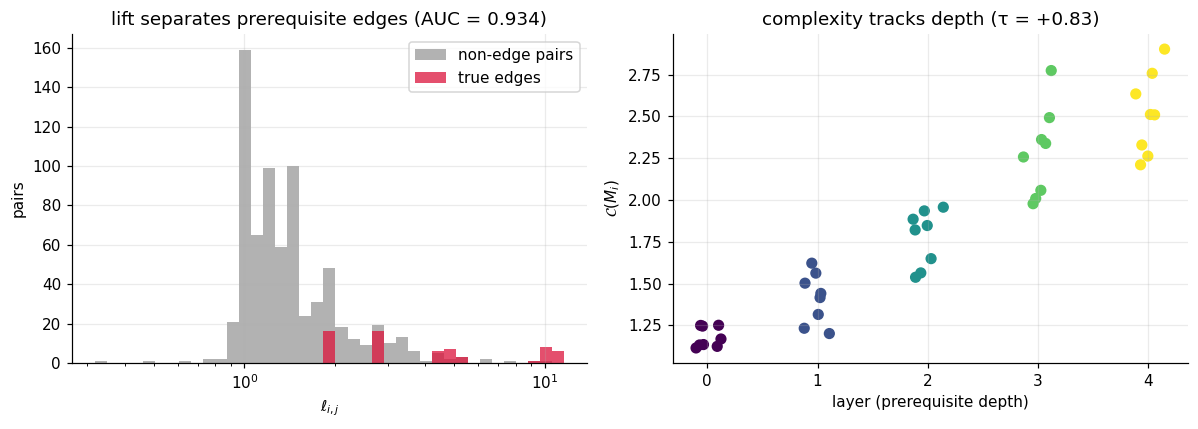

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

bins = np.logspace(np.log10(max(lift[upper].min(), 1e-3)), np.log10(lift[upper].max()), 40)
ax1.hist(lift[upper][is_edge == 0], bins=bins, alpha=0.6, label="non-edge pairs", color="grey")
ax1.hist(lift[upper][is_edge == 1], bins=bins, alpha=0.75, label="true edges", color="crimson")
ax1.set(xscale="log", xlabel=r"$\ell_{i,j}$", ylabel="pairs",
        title=f"lift separates prerequisite edges (AUC = {auc:.3f})")
ax1.legend()

ax2.scatter(layer_of + rng.uniform(-0.15, 0.15, N_MARKERS), complexity,
            c=layer_of, cmap="viridis", s=40)
ax2.set(xlabel="layer (prerequisite depth)", ylabel=r"$\mathcal{C}(M_i)$",
        title=f"complexity tracks depth (τ = {tau_layer:+.2f})")

fig.tight_layout()
plt.show()

---
## 3. The complexity–velocity sign is not built in

**Velocity** is the marginal publication frequency $v(M_i) = P(M_i = 1)$.
Nothing in the definition of $\mathcal{C}$ refers to it, which is what makes the
empirical negative relationship a genuine external validation rather than an
identity.

In this particular simulation the relationship *is* negative — deep markers were
given almost no exogenous baseline, so they are both complex and rare. But that
was a modelling choice. Sweeping `u_ramp`, the rate at which the exogenous
baseline $u_i$ grows with depth, and leaving everything else fixed, the sign of
Kendall's $\tau$ changes. The model permits either sign; the corpus picks one.

Kendall tau(complexity, velocity) = -0.774  (p = 2.0e-12)


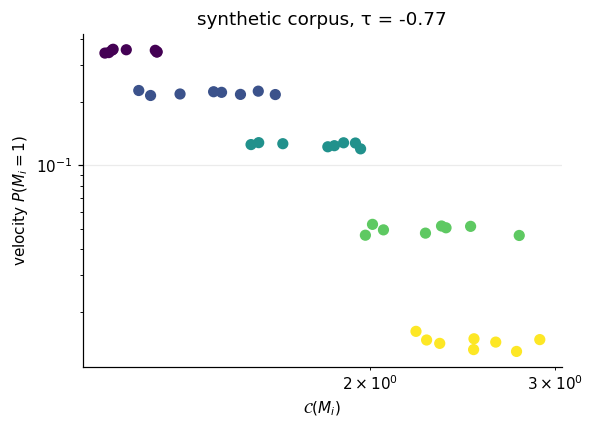

In [6]:
tau_cv, p_cv = stats.kendalltau(complexity, velocity)
print(f"Kendall tau(complexity, velocity) = {tau_cv:+.3f}  (p = {p_cv:.1e})")

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(complexity, velocity, c=layer_of, cmap="viridis", s=40)
ax.set(xscale="log", yscale="log", xlabel=r"$\mathcal{C}(M_i)$",
       ylabel=r"velocity $P(M_i=1)$",
       title=f"synthetic corpus, τ = {tau_cv:+.2f}")
fig.tight_layout()
plt.show()

In [7]:
sweep = []
for u_ramp in [0.5, 1.0, 2.0, 4.0]:
    sweep_rng = np.random.default_rng(11)
    C_s, u_s, _ = layered_scm(30, 5, n_parents=2, w0=0.8, decay=0.7,
                              u_root=0.05, u_ramp=u_ramp, rng=sweep_rng)
    docs_s = simulate_markers(C_s, u_s, n_docs=8_000, rng=sweep_rng)
    lift_s, vel_s = lift_matrix_from_documents(docs_s.astype(float))
    tau_s, p_s = stats.kendalltau(complexity_from_lift(lift_s), vel_s)
    sweep.append({"u_ramp": u_ramp, "kendall_tau": tau_s, "p_value": p_s,
                  "min_velocity": vel_s.min(), "max_velocity": vel_s.max()})

sweep = pd.DataFrame(sweep).set_index("u_ramp")
print(sweep.round(3).to_string())
print(f"\ntau ranges from {sweep.kendall_tau.min():+.2f} to {sweep.kendall_tau.max():+.2f}"
      " — the sign is a property of the corpus, not of the framework.")

        kendall_tau  p_value  min_velocity  max_velocity
u_ramp                                                  
0.5          -0.318    0.014         0.008         0.065
1.0           0.302    0.019         0.045         0.103
2.0          -0.586    0.000         0.045         0.897
4.0          -0.686    0.000         0.045         1.000

tau ranges from -0.69 to +0.30 — the sign is a property of the corpus, not of the framework.


---
## 4. Recovering the semantic clusters

Complexity is a *within-cluster* quantity: the lift $\ell_{i,j}$ is only
meaningful when $M_i$ and $M_j$ share a semantic register. The clusters
therefore have to be recovered from the data first, using the lift-derived
dissimilarity

$$D_{i,j} = \log\!\left(1 + \frac{1}{\ell_{i,j}}\right),$$

fed to UMAP as a precomputed metric and then partitioned by HDBSCAN.

The benchmark is deliberately **$C$-blind**: no method is allowed to read the
generating matrix, all three see only the lift estimated from simulated
documents — exactly the informational regime of the real pipeline. Below is the
full published run (`cluster_recovery_fair.py`, 20 replications per noise
level), followed by a small live replication you can re-run here.

In [8]:
bench = pd.read_csv(RESULTS_DIR / "cluster_recovery_fair_summary.csv")
trials = pd.read_csv(RESULTS_DIR / "cluster_recovery_fair.csv")

table = bench.pivot(index="p_inter", columns="label", values="mean")[
    ["K-Means", "UMAP (euclidean)", "UMAP + complexity"]]
print("Mean ARI over 20 replications per noise level")
print("(100 markers, 5 clusters, p_intra=0.99, 5,000 simulated documents)\n")
print(table.round(3).to_string())

print("\nPaired Wilcoxon, UMAP + complexity vs each baseline:")
for p_inter, grp in trials.groupby("p_inter"):
    d_km = grp.umap_complexity - grp.kmeans
    d_eu = grp.umap_complexity - grp.umap_euclidean
    print(f"  p_inter={p_inter:.2f}"
          f"   vs k-means  Δ={d_km.mean():+.3f} (p={stats.wilcoxon(d_km).pvalue:.1e})"
          f"   |   vs UMAP-euclidean  Δ={d_eu.mean():+.3f} (p={stats.wilcoxon(d_eu).pvalue:.1e})")

Mean ARI over 20 replications per noise level
(100 markers, 5 clusters, p_intra=0.99, 5,000 simulated documents)

label    K-Means  UMAP (euclidean)  UMAP + complexity
p_inter                                              
0.01       0.531             0.792              0.880
0.05       0.244             0.416              0.735
0.10       0.128             0.237              0.553
0.20       0.198             0.187              0.401
0.30       0.234             0.216              0.266

Paired Wilcoxon, UMAP + complexity vs each baseline:
  p_inter=0.01   vs k-means  Δ=+0.349 (p=5.7e-06)   |   vs UMAP-euclidean  Δ=+0.088 (p=7.0e-02)
  p_inter=0.05   vs k-means  Δ=+0.491 (p=1.9e-05)   |   vs UMAP-euclidean  Δ=+0.319 (p=4.8e-04)
  p_inter=0.10   vs k-means  Δ=+0.425 (p=1.9e-06)   |   vs UMAP-euclidean  Δ=+0.316 (p=1.9e-06)
  p_inter=0.20   vs k-means  Δ=+0.203 (p=1.9e-05)   |   vs UMAP-euclidean  Δ=+0.214 (p=3.2e-04)
  p_inter=0.30   vs k-means  Δ=+0.032 (p=2.6e-01)   |   vs UMAP-euclid

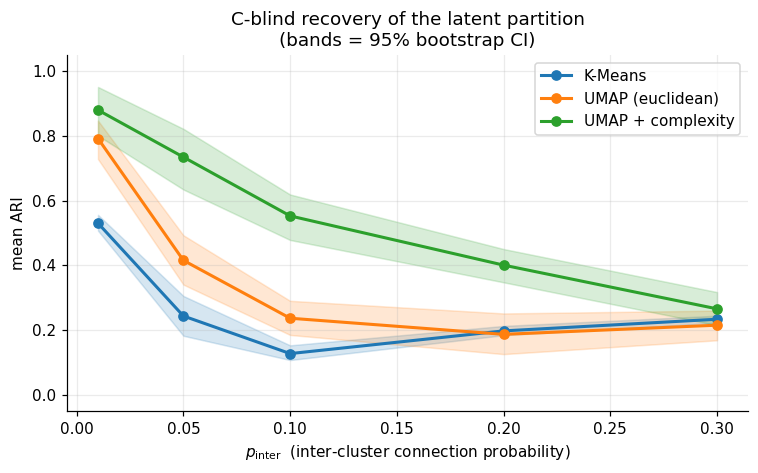

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.4))
for label, colour in [("K-Means", "tab:blue"),
                      ("UMAP (euclidean)", "tab:orange"),
                      ("UMAP + complexity", "tab:green")]:
    sub = bench[bench.label == label].sort_values("p_inter")
    ax.plot(sub.p_inter, sub["mean"], marker="o", color=colour, lw=2, label=label)
    ax.fill_between(sub.p_inter, sub.boot_ci_low, sub.boot_ci_high, color=colour, alpha=0.18)

ax.set(xlabel=r"$p_{\mathrm{inter}}$  (inter-cluster connection probability)",
       ylabel="mean ARI", ylim=(-0.05, 1.05),
       title="C-blind recovery of the latent partition\n(bands = 95% bootstrap CI)")
ax.legend()
fig.tight_layout()
plt.show()

A live replication at reduced scale (60 markers, 3 clusters, 2 000 documents,
3 trials) so the notebook stays fast. Three trials is far too few to be
conclusive — the shipped 20-replication run above is the authoritative result —
but it does exercise the full code path end to end.

In [10]:
from cluster_recovery_fair import run_fair

DEMO_P_INTER, DEMO_TRIALS = 0.10, 3

live = []
for trial in range(DEMO_TRIALS):
    trial_rng = np.random.default_rng(7_000 + trial)
    C_c, labels_c = generate_cluster_markers(3, 60, p_intra=0.99, w_min=0.8, w_max=1.0,
                                             p_inter=DEMO_P_INTER, rng=trial_rng)
    ari_km, ari_eucl, ari_D = run_fair(C_c, labels_c, n_sim=2_000, rng=trial_rng)
    live.append({"trial": trial, "k-means": ari_km,
                 "UMAP (euclidean)": ari_eucl, "UMAP + complexity": ari_D})

live = pd.DataFrame(live).set_index("trial")
print(f"Live replication — 60 markers, 3 clusters, 2,000 documents, p_inter={DEMO_P_INTER}\n")
print(live.round(3).to_string())
print("\nmean ARI:", {k: round(v, 3) for k, v in live.mean().items()})

Live replication — 60 markers, 3 clusters, 2,000 documents, p_inter=0.1

       k-means  UMAP (euclidean)  UMAP + complexity
trial                                              
0        0.069             0.175              0.257
1        0.337             0.365              0.513
2        0.096             0.005              0.248

mean ARI: {'k-means': 0.168, 'UMAP (euclidean)': 0.182, 'UMAP + complexity': 0.339}


---
## 5. Recovering the dependency graph with PC

Within a recovered cluster, the PC algorithm reconstructs the skeleton of the
dependency DAG from conditional-independence tests. This is what grounds the
causal reading of the lift. `empirical_pc_tests.py` runs this across nine DAG
topologies; here is one graph, scored by $F_1$ on the undirected skeleton.

true edges      : 18
recovered edges : 18
skeleton F1     : 1.000


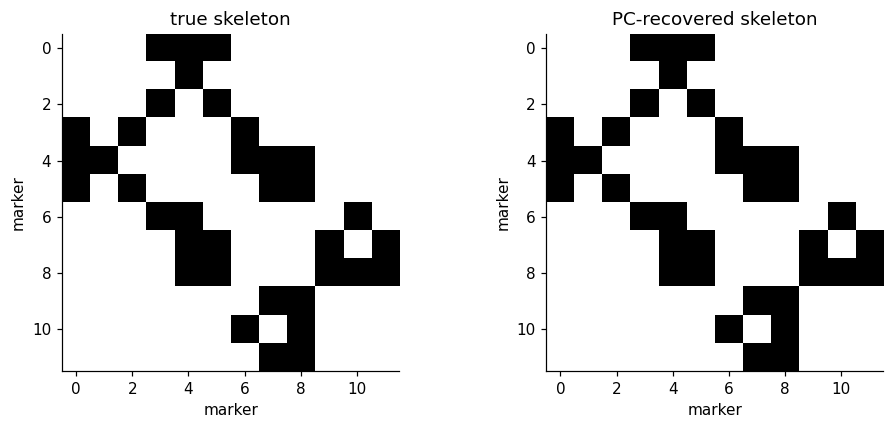

In [11]:
from causallearn.search.ConstraintBased.PC import pc
from empirical_pc_tests import compute_f1

P_PC = 12
pc_rng = np.random.default_rng(SEED)
C_pc, u_pc, _ = layered_scm(P_PC, 4, n_parents=2, w0=0.7, decay=0.85,
                            u_root=0.30, u_ramp=1.0, rng=pc_rng)
u_pc[u_pc < 0.30] = 0.05
docs_pc = simulate_markers(C_pc, u_pc, n_docs=8_000, rng=pc_rng)

cg = pc(docs_pc, alpha=0.01, indep_test="chisq", stable=True, show_progress=False)
estimated = (np.abs(cg.G.graph) > 0).astype(int)
estimated = np.maximum(estimated, estimated.T)
true_skeleton = np.maximum((C_pc > 0).astype(int), (C_pc > 0).T.astype(int))

triu = np.triu_indices(P_PC, k=1)
print(f"true edges      : {true_skeleton[triu].sum()}")
print(f"recovered edges : {estimated[triu].sum()}")
print(f"skeleton F1     : {compute_f1(true_skeleton, estimated):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, mat, title in [(axes[0], true_skeleton, "true skeleton"),
                       (axes[1], estimated, "PC-recovered skeleton")]:
    ax.imshow(mat, cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
    ax.set(title=title, xlabel="marker", ylabel="marker")
    ax.grid(False)
fig.tight_layout()
plt.show()

---
## 6. The stylized fact on the CausalityLink corpus

Everything above ran on synthetic data. This section reads the **precomputed**
outputs of the full pipeline on the January 2025 CausalityLink snapshot —
1.18 M articles, 6 500 markers, 21 clusters — committed under `clusters/`.

To regenerate them from the corpus (not shipped):

```bash
python complexity_clusters.py --root data/causalitylink_sample --all-clusters
```

In [12]:
THEMES = {
    0: "Mining", 1: "Science", 2: "Politics", 3: "Construction", 4: "Chemistry",
    5: "Vehicles", 6: "Aviation", 7: "Tourism", 8: "Education", 9: "Apparel",
    10: "Communication", 11: "Tech", 12: "China", 13: "Food & Beverage",
    14: "Insurance", 15: "Banks", 16: "Investment", 17: "Health",
    18: "Cybersecurity 1/2", 19: "Cybersecurity 2/2", 20: "Public sector",
}

corpus = pd.read_csv(CLUSTERS_DIR / "all_clusters_stats.csv", index_col="cluster_id")
corpus.insert(0, "theme", corpus.index.map(THEMES))

corpus[["theme", "n_kpi", "n_articles", "mean_intra_lift", "mean_external_lift",
        "beta1", "beta1_ci_low", "beta1_ci_high", "r2",
        "kendall_tau", "pearson_r"]].round(3)

,theme,n_kpi,n_articles,mean_intra_lift,mean_external_lift,beta1,beta1_ci_low,beta1_ci_high,r2,kendall_tau,pearson_r
cluster_id,,,,,,,,,,,
0,Mining,466,1126287,39.526,4.116,-1.568,-1.645,-1.491,0.775,-0.734,-0.881
1,Science,112,643982,144.318,3.798,-1.230,-1.350,-1.109,0.787,-0.781,-0.887
2,Politics,140,302207,12.157,1.372,-0.614,-1.003,-0.224,0.066,-0.242,-0.256
3,Construction,102,518085,192.961,3.831,-1.225,-1.299,-1.151,0.915,-0.904,-0.956
4,Chemistry,461,281106,31.428,3.302,-0.587,-0.709,-0.465,0.163,-0.282,-0.404
5,Vehicles,331,270800,144.250,3.249,-0.776,-0.875,-0.676,0.418,-0.436,-0.647
6,Aviation,86,51339,129.886,2.110,-0.800,-1.157,-0.444,0.192,-0.326,-0.438
7,Tourism,108,99978,105.597,2.721,-0.464,-0.644,-0.283,0.197,-0.335,-0.444
8,Education,147,137604,19.761,2.704,-0.758,-0.954,-0.563,0.288,-0.356,-0.537


In [13]:
n = len(corpus)
print(f"clusters                                : {n}")
print(f"negative log-log slope  beta1 < 0       : {(corpus.beta1 < 0).sum()}/{n}")
print(f"95% CI for beta1 strictly below zero    : {(corpus.beta1_ci_high < 0).sum()}/{n}")
print(f"negative Kendall tau                    : {(corpus.kendall_tau < 0).sum()}/{n}")
print(f"negative Pearson rho                    : {(corpus.pearson_r < 0).sum()}/{n}")
print(f"intra-cluster lift > external lift      : {(corpus.mean_intra_lift > corpus.mean_external_lift).sum()}/{n}")

clusters                                : 21
negative log-log slope  beta1 < 0       : 21/21
95% CI for beta1 strictly below zero    : 20/21
negative Kendall tau                    : 21/21
negative Pearson rho                    : 21/21
intra-cluster lift > external lift      : 21/21


The last line is the coherence check on the clustering: markers inside a cluster
co-occur far more than expected under independence ($\bar L_{\text{intra}}$
between 12 and 211), while cross-cluster co-occurrence stays near the
independence baseline ($\bar L_{\text{ext}}$ between 1.4 and 4.1).

The first four are the stylized fact. Note the one cluster whose $\beta_1$
confidence interval straddles zero (17 · Health): the relationship there is not
well captured by a log–log linear fit, but Kendall's $\tau$ and Pearson's $\rho$
stay negative throughout.

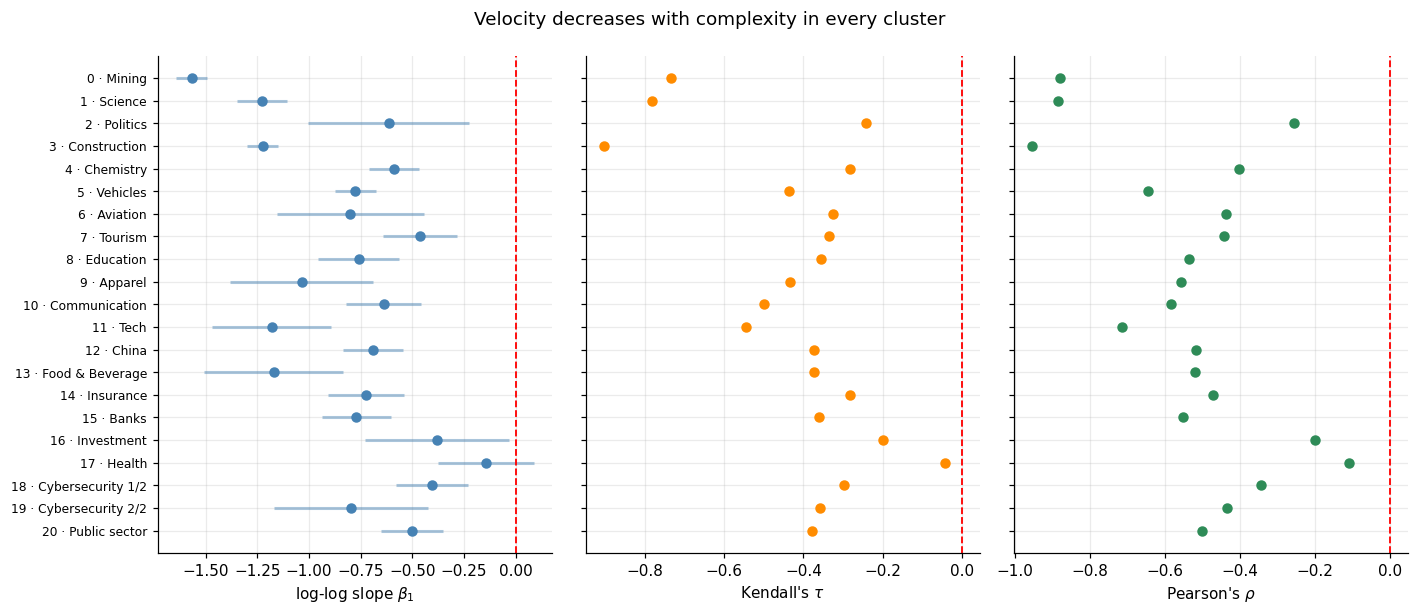

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5.6), sharey=True)
y = np.arange(n)

for ax, (col, label, colour) in zip(axes, [
    ("beta1", r"log-log slope $\beta_1$", "steelblue"),
    ("kendall_tau", r"Kendall's $\tau$", "darkorange"),
    ("pearson_r", r"Pearson's $\rho$", "seagreen"),
]):
    ax.scatter(corpus[col], y, color=colour, s=34, zorder=3)
    if col == "beta1":
        ax.hlines(y, corpus.beta1_ci_low, corpus.beta1_ci_high,
                  color=colour, alpha=0.45, lw=2, zorder=2)
    ax.axvline(0, color="red", ls="--", lw=1.2)
    ax.set(xlabel=label)

axes[0].set_yticks(y)
axes[0].set_yticklabels([f"{i} · {t}" for i, t in zip(corpus.index, corpus.theme)], fontsize=8)
axes[0].invert_yaxis()
fig.suptitle("Velocity decreases with complexity in every cluster", y=0.99)
fig.tight_layout()
plt.show()

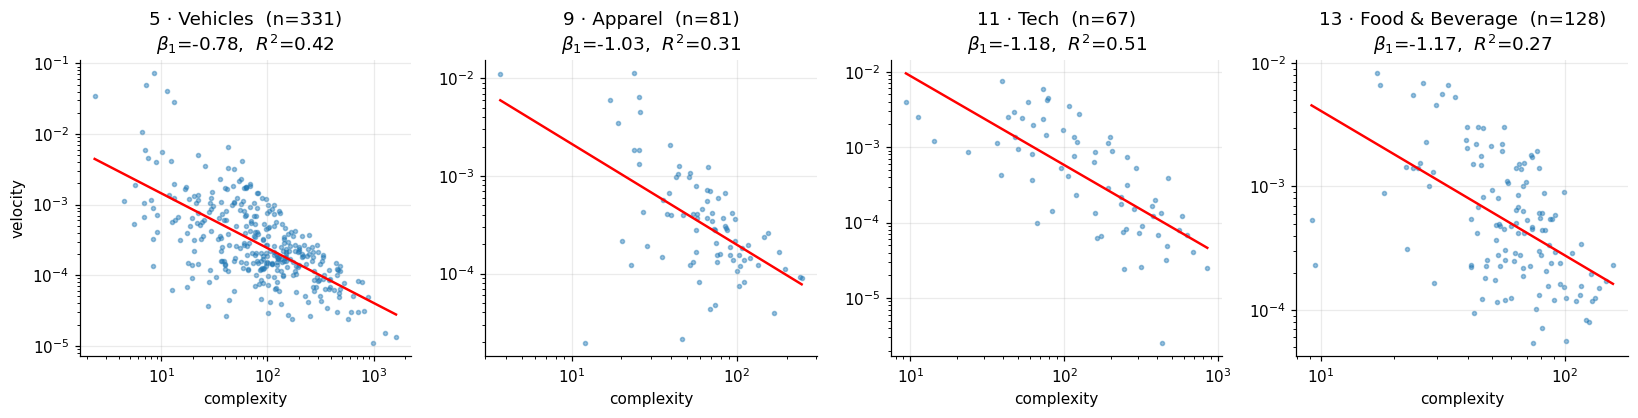

In [15]:
SHOWCASE = [5, 9, 11, 13]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.9))
for ax, cid in zip(axes, SHOWCASE):
    d = pd.read_csv(CLUSTERS_DIR / f"cluster_{cid}_all_markers.csv").dropna()
    d = d[(d.complexity > 0) & (d.velocity > 0)]
    reg = fit_loglog_regression(d.complexity.to_numpy(), d.velocity.to_numpy())

    ax.scatter(d.complexity, d.velocity, s=7, alpha=0.45)
    xs = np.array([d.complexity.min(), d.complexity.max()])
    ax.plot(xs, np.exp(reg["beta0"]) * xs ** reg["beta1"], color="red", lw=1.6)
    ax.set(xscale="log", yscale="log", xlabel="complexity",
           title=f"{cid} · {THEMES[cid]}  (n={len(d)})\n"
                 rf"$\beta_1$={reg['beta1']:.2f},  $R^2$={reg['r2']:.2f}")

axes[0].set_ylabel("velocity")
fig.tight_layout()
plt.show()

What the ordering looks like inside a cluster — generic notions at the bottom,
specific product lines at the top:

In [16]:
extremes = pd.read_csv(CLUSTERS_DIR / "cluster_11_top_bottom.csv")
print("Cluster 11 (Tech) — 10 simplest and 10 most complex markers\n")
print(extremes.to_string(index=False))

Cluster 11 (Tech) — 10 simplest and 10 most complex markers

                                 marker  complexity   rank
                     writing_instrument    9.344836 bottom
                    feature_price_point   11.208493 bottom
                                 xiaomi   14.154290 bottom
                         back_to_school   23.719514 bottom
                                fp_corp   36.320348 bottom
                               firmware   38.552090 bottom
                                 nvidia   39.580416 bottom
                                 tablet   43.242679 bottom
technology_hardware_storage_peripherals   47.120325 bottom
                         display_panels   47.634416 bottom
                                core_i7  428.854271    top
            elitegroup_computer_systems  432.879304    top
                              elitebook  461.746228    top
                  microsoft_surface_pro  462.498878    top
                              amd_ryzen  473.462347   

---
## 7. Cross-validation against an LLM judge

An independent check that $\mathcal{C}$ matches human intuition: an LLM
(Ministral-8B-Instruct) scored every marker 1–10 for complexity, given only the
*definition* of complexity and the marker list — never our scores. Because the
judge rates markers "relative to the other concepts in this list", the scores
are comparable only *within* a cluster, so agreement is measured per cluster and
the terciles are computed per cluster.

Regenerate with `python llm_judge.py` (needs `requirements-llm.txt`).

In [17]:
from llm_judge import scores_to_categories

judge_rows = []
pooled = {"simple": [], "intermediate": [], "complex": []}

for path in sorted(CLUSTERS_DIR.glob("cluster_*_llm_classification.csv"),
                   key=lambda p: int(p.stem.split("_")[1])):
    cid = int(path.stem.split("_")[1])
    d = pd.read_csv(path).dropna(subset=["complexity", "llm_score"])
    if len(d) < 10:
        continue

    # Spearman is undefined when the judge gave every marker the same score.
    rho, pval = ((np.nan, np.nan) if d.llm_score.nunique() < 2
                 else stats.spearmanr(d.complexity, d.llm_score))
    judge_rows.append({"cluster_id": cid, "theme": THEMES.get(cid, "?"), "n": len(d),
                       "n_distinct_scores": d.llm_score.nunique(),
                       "spearman_rho": rho, "p_value": pval})

    # min-max normalise log-complexity within the cluster, then pool by tercile
    log_c = np.log(d.complexity.to_numpy())
    span = log_c.max() - log_c.min()
    normalised = (log_c - log_c.min()) / span if span > 0 else np.zeros_like(log_c)
    for category, value in zip(scores_to_categories(d.llm_score), normalised):
        if category in pooled:
            pooled[category].append(value)

judge = pd.DataFrame(judge_rows).set_index("cluster_id")
scored = judge.dropna(subset=["spearman_rho"])

print(f"clusters with a usable Spearman rho : {len(scored)}/{len(judge)}")
print(f"of those, rho > 0                   : {(scored.spearman_rho > 0).sum()}/{len(scored)}")
print(f"mean rho                            : {scored.spearman_rho.mean():+.3f}\n")
for category in ("simple", "intermediate", "complex"):
    values = np.asarray(pooled[category])
    print(f"median normalised log-complexity, {category:<12}: "
          f"{np.median(values):.2f}   (n = {len(values)})")

judge.round(3)

clusters with a usable Spearman rho : 20/21
of those, rho > 0                   : 19/20
mean rho                            : +0.262

median normalised log-complexity, simple      : 0.43   (n = 1200)
median normalised log-complexity, intermediate: 0.54   (n = 1193)
median normalised log-complexity, complex     : 0.60   (n = 1183)


,theme,n,n_distinct_scores,spearman_rho,p_value
cluster_id,,,,,
0,Mining,466,5,0.250,0.000
1,Science,112,5,0.080,0.402
2,Politics,140,5,0.211,0.012
3,Construction,102,4,0.177,0.075
4,Chemistry,461,3,0.155,0.001
5,Vehicles,331,4,0.456,0.000
6,Aviation,86,5,0.165,0.128
7,Tourism,108,4,0.236,0.014
8,Education,147,5,0.466,0.000


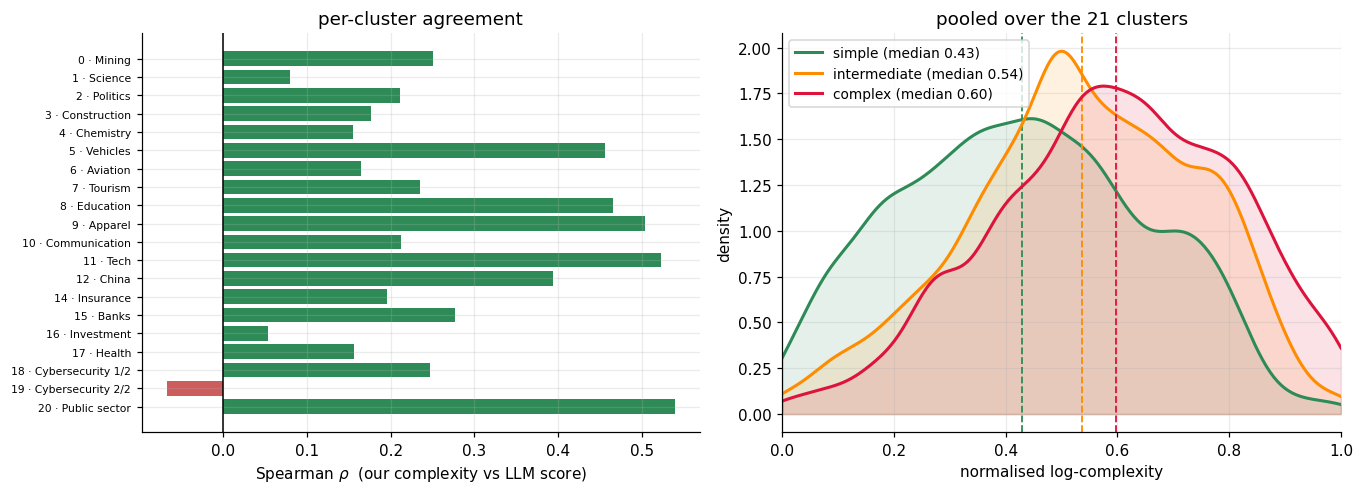

In [18]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 4.6))

axL.barh(np.arange(len(scored)), scored.spearman_rho,
         color=["seagreen" if v > 0 else "indianred" for v in scored.spearman_rho])
axL.set_yticks(np.arange(len(scored)))
axL.set_yticklabels([f"{i} · {t}" for i, t in zip(scored.index, scored.theme)], fontsize=7)
axL.invert_yaxis()
axL.axvline(0, color="black", lw=1)
axL.set(xlabel=r"Spearman $\rho$  (our complexity vs LLM score)",
        title="per-cluster agreement")

grid = np.linspace(0, 1, 300)
for category, colour in [("simple", "seagreen"),
                         ("intermediate", "darkorange"),
                         ("complex", "crimson")]:
    values = np.asarray(pooled[category])
    bandwidth = max(0.7 * 1.06 * values.std(ddof=1) * len(values) ** -0.2, 1e-3)
    density = np.exp(-0.5 * ((grid[:, None] - values) / bandwidth) ** 2).sum(axis=1)
    density /= len(values) * bandwidth * np.sqrt(2 * np.pi)
    axR.plot(grid, density, color=colour, lw=2,
             label=f"{category} (median {np.median(values):.2f})")
    axR.fill_between(grid, density, color=colour, alpha=0.12)
    axR.axvline(np.median(values), color=colour, ls="--", lw=1.2)

axR.set(xlabel="normalised log-complexity", ylabel="density", xlim=(0, 1),
        title="pooled over the 21 clusters")
axR.legend(fontsize=9)
fig.tight_layout()
plt.show()

The tercile medians shift monotonically to the right (0.43 → 0.54 → 0.60): what
the LLM calls complex is what the metric scores as complex. Agreement is
positive but modest — the judge uses a coarse 1–10 integer scale with heavy
ties, and in one cluster (13 · Food & Beverage) it gave every marker the same
score, which makes the rank correlation undefined there.

---
## 8. Source selection as a budget-constrained problem

The practical payoff. A team curating a retrieval corpus monitors a theme of
target complexity $C^{*}$. For each source $s$ it picks a *working complexity*
$C_s \le C^{*}$ — operationally, the retriever's similarity threshold. Relaxing
it by $\delta_s = C^{*} - C_s$ buys velocity at the cost of thematic precision:

$$\max_{\boldsymbol\delta \ge 0} \sum_s \Bigl[(v_s^0 + \ell_s \delta_s) - \tfrac{\gamma}{2}\delta_s^2\Bigr]
\quad\text{s.t.}\quad \sum_s (v_s^0 + \ell_s\delta_s) \le B,$$

with $v_s^0 = A_s (C^{*})^{-\beta_s}$ the baseline on-topic velocity and
$\ell_s = \beta_s v_s^0 / C^{*}$ the responsiveness. Both are read straight off
the per-source log–log regression. The solution is

$$\boxed{\;\delta_s^{*} = \mu\,\ell_s,\qquad \mu = \frac{B - V^0}{\sum_s \ell_s^2}\;}$$

so blurring is allocated **in proportion to responsiveness**. Below, a portfolio
of five sources; the specialists have steeper slopes and — at this high target
complexity, where they stay competitive on baseline coverage — the larger
$\ell_s$, so they are the ones relaxed most.

In [19]:
C_STAR = 40.0           # target complexity of the monitored theme
GAMMA = 2.0             # intolerance to thematic noise
MAX_RELAXATION = 0.20   # size the budget so the largest blurring is 20% of C*

sources = pd.DataFrame({
    "source": ["Generalist wire", "Generalist daily", "Sector weekly",
               "Trade specialist", "Niche analyst"],
    "v0":     [600.0, 500.0, 420.0, 380.0, 300.0],   # on-topic docs/month at C*
    "beta_s": [0.35, 0.55, 1.00, 1.50, 2.00],        # log-log slope, estimated per source
}).set_index("source")

sources["alpha_s"] = np.log(sources.v0 * C_STAR ** sources.beta_s)
sources["ell"] = sources.beta_s * sources.v0 / C_STAR

V0 = sources.v0.sum()
sum_ell_sq = (sources.ell ** 2).sum()
mu = MAX_RELAXATION * C_STAR / sources.ell.max()
B = V0 + mu * sum_ell_sq

sources["delta_star"] = mu * sources.ell
sources["C_working"] = C_STAR - sources.delta_star
sources["velocity"] = sources.v0 + mu * sources.ell ** 2
sources["precision_loss"] = 0.5 * GAMMA * sources.delta_star ** 2

optimal_value = B - GAMMA * (B - V0) ** 2 / (2 * sum_ell_sq)

print(sources[["v0", "beta_s", "ell", "delta_star", "C_working",
               "velocity", "precision_loss"]].round(2).to_string())
print(f"\nC* = {C_STAR}      gamma = {GAMMA}")
print(f"V0 = {V0:,.0f} docs/month      B = {B:,.0f} docs/month      mu = {mu:.3f}")
print(f"binding constraint,  sum_s v_s = B     : {np.isclose(sources.velocity.sum(), B)}")
print(f"interior solution,   0 < delta* <= C*  : "
      f"{bool(((sources.delta_star > 0) & (sources.delta_star <= C_STAR)).all())}")
print(f"optimal objective    V*                : {optimal_value:,.1f} docs/month")

                     v0  beta_s    ell  delta_star  C_working  velocity  precision_loss
source                                                                                 
Generalist wire   600.0    0.35   5.25        2.80      37.20    614.70            7.84
Generalist daily  500.0    0.55   6.88        3.67      36.33    525.21           13.44
Sector weekly     420.0    1.00  10.50        5.60      34.40    478.80           31.36
Trade specialist  380.0    1.50  14.25        7.60      32.40    488.30           57.76
Niche analyst     300.0    2.00  15.00        8.00      32.00    420.00           64.00

C* = 40.0      gamma = 2.0
V0 = 2,200 docs/month      B = 2,527 docs/month      mu = 0.533
binding constraint,  sum_s v_s = B     : True
interior solution,   0 < delta* <= C*  : True
optimal objective    V*                : 2,352.6 docs/month


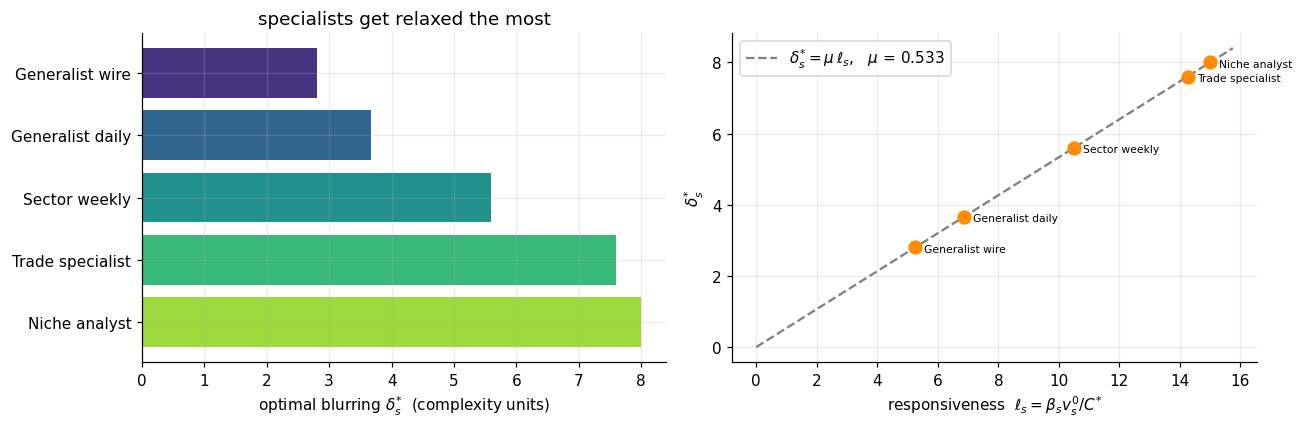

In [20]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4))

axA.barh(sources.index, sources.delta_star,
         color=plt.cm.viridis(np.linspace(0.15, 0.85, len(sources))))
axA.invert_yaxis()
axA.set(xlabel=r"optimal blurring $\delta_s^{*}$  (complexity units)",
        title="specialists get relaxed the most")

axB.scatter(sources.ell, sources.delta_star, s=70, color="darkorange", zorder=3)
line = np.linspace(0, sources.ell.max() * 1.05, 50)
axB.plot(line, mu * line, color="grey", ls="--",
         label=rf"$\delta_s^{{*}} = \mu\,\ell_s$,   $\mu$ = {mu:.3f}")
for name, row in sources.iterrows():
    axB.annotate(name, (row.ell, row.delta_star), textcoords="offset points",
                 xytext=(6, -3), fontsize=7)
axB.set(xlabel=r"responsiveness  $\ell_s = \beta_s v_s^0 / C^{*}$",
        ylabel=r"$\delta_s^{*}$")
axB.legend()

fig.tight_layout()
plt.show()

---
## Where to go next

| To do this | Run |
|---|---|
| Full pipeline on the corpus | `python complexity_clusters.py --root <data> --all-clusters` |
| Four-cluster complexity–velocity figure | `python analyze_selected_clusters.py --root <data>` |
| Per-publisher breakdown | `python complexity_clusters_publisher.py --root <data> --cluster-id 12` |
| Intra-cluster causal graphs | `python peter_clark_scm.py --root <data> --clusters 5 11` |
| Full cluster-recovery benchmark | `python cluster_recovery_fair.py` |
| PC skeleton F1 table from the paper | `python empirical_pc_tests.py --p-min 12 --p-max 12 --n-obs 30000 --reps 20` |
| LLM-judge scoring | `python llm_judge.py` |

Every script takes `--help` and `--seed`. See the README for the data layout the
`<data>` scripts expect.